# RRR：建模、公式导出与动力学分解

这个 Notebook 检查三轴 RRR 的正运动学、雅可比和动力学公式，再导出可调用的 Python / C 函数，用理想数据辨识基参数。最后给出一个可选的惯性参数恢复示例。

MDH 表在 `src/robot_model/robots/rrr.py`，MuJoCo 参考模型是 `rrr_arm.xml`。本例数据来自解析轨迹和 `mj_inverse`，没有闭环跟踪或编码器微分；加噪声时也只扰动力矩。[README](../../README.md) 展示的闭环实验使用另一套采集和预处理流程。

首次运行先在仓库根目录安装：`pip install -e ".[sim,ident,viz,dev]"`。从第一格顺序运行；符号导出会写入 `outputs/rrr_symbolic/`，可选恢复默认跳过。只想先看辨识接口，可运行更短的 [identification.ipynb](identification.ipynb)。


In [ ]:
import importlib.util
import json
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import sympy


def _project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "src" / "robot_model" / "__init__.py"
        ).is_file():
            return candidate
    raise FileNotFoundError("找不到含 pyproject.toml 和 src/robot_model 的项目根目录")


_ROOT = _project_root(Path.cwd().resolve())
_SRC = _ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from robot_model import Robot
from robot_model.data import add_noise, sample_trajectory
from robot_model.excitation import search_excitation
from robot_model.identification import (
    DynamicsDecomposer,
    RecoveryConfig,
    identify,
    pack_inertial_parameters,
    parameter_error,
    predict_torque,
    recover_inertial_parameters,
)
from robot_model.robots.rrr import (
    RRR_BODY_NAMES,
    RRR_MDH_PARMS,
    RRR_TOOL_OFFSET,
    rrr_xml_path,
)
from robot_model.simulation.reference import MujocoReference

sympy.init_printing()
OUT = _ROOT / "outputs" / "rrr_symbolic"
OUT.mkdir(parents=True, exist_ok=True)
print("robot_model:", _ROOT)
print("导出目录:", OUT)


## 1. 正运动学

MDH 参数表定义几何；`frames.T[i]` 是基座到连杆 `i` 的齐次变换。

In [2]:
robot = Robot.from_mdh("rrr_arm", RRR_MDH_PARMS)
robot.print_dh_table()
print("dof =", robot.dof, " convention =", robot.convention)
print("关节变量:", list(robot.q))

Joint,a,d,α,θ,关节类型
Joint1,0,0.3,0,q1,转动关节
Joint2,0,0,-pi/2,q2,转动关节
Joint3,0.28,0.05,0,q3,转动关节


dof = 3  convention = modified
关节变量: [q1, q2, q3]


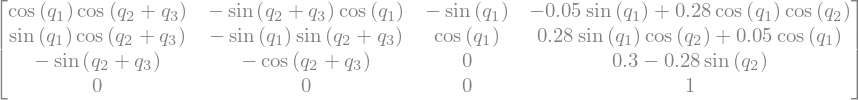

In [3]:
# 末端位姿（符号）。trigsimp 后可读性好一些
T_end = sympy.trigsimp(robot.forward_kinematics())
T_end

In [4]:
# 与 MuJoCo 对拍：body 帧与 MDH 帧逐帧对齐
model = mujoco.MjModel.from_xml_path(str(rrr_xml_path()))
ref = MujocoReference(model, RRR_BODY_NAMES)

q_test = np.array([0.3, -0.6, 0.9])
T_mj = ref.body_poses(q_test)

for i in range(robot.dof):
    T_sym = robot.fk_numpy(q_test, link=i)
    pos_err = np.linalg.norm(T_sym[:3, 3] - T_mj[i][:3, 3])
    rot_err = np.linalg.norm(T_sym[:3, :3] - T_mj[i][:3, :3])
    print(f"link{i + 1}: 位置误差 {pos_err:.2e}  姿态误差 {rot_err:.2e}")

link1: 位置误差 0.00e+00  姿态误差 1.92e-16
link2: 位置误差 0.00e+00  姿态误差 9.56e-16
link3: 位置误差 1.49e-16  姿态误差 1.08e-15


In [5]:
# 顺带验证 MDH → PoE 互转后正运动学不变
poe = robot.to_poe()
cmp = robot.compare_fk(poe, q_test)
print(f"MDH vs PoE: 位置 {cmp['pos_err']:.2e}  姿态 {cmp['rot_err']:.2e}")

MDH vs PoE: 位置 3.10e-17  姿态 0.00e+00


## 2. 几何雅可比

`J[i]` 对应连杆 `i` 原点，线速度和角速度均在基座坐标系表达：`[v; omega] = J dq`。MuJoCo 的速度传感器位于工具端，因此比较前需要计入工具相对连杆原点的偏置。


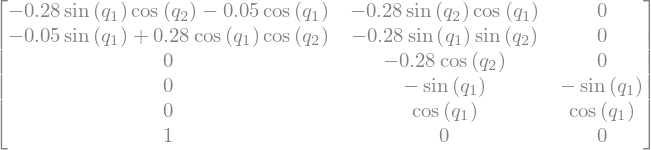

In [6]:
kin = robot.kinematics
J_end = sympy.trigsimp(kin.J[-1])
J_end

In [7]:
# 用 MuJoCo 的 tool 速度传感器验雅可比：tool 相对 link3 有偏置，需搬运
dq_test = np.array([0.5, -0.4, 0.7])
ref.forward(q_test, dq_test)
v_tool_mj = ref.sensor("tool_linvel")

J_fun = sympy.lambdify(list(robot.q), kin.J[-1], "numpy")
J_num = np.asarray(J_fun(*q_test), dtype=float)
twist = J_num @ dq_test  # [v_link3; omega]
v_link, omega = twist[:3], twist[3:]

R3 = robot.fk_numpy(q_test, link=2)[:3, :3]
r = R3 @ np.array(RRR_TOOL_OFFSET)
v_tool_sym = v_link + np.cross(omega, r)
print("符号:", v_tool_sym)
print("MuJoCo:", v_tool_mj)
print(f"误差 {np.abs(v_tool_sym - v_tool_mj).max():.2e}")

符号: [-0.16813386  0.1789391   0.02938538]
MuJoCo: [-0.16813386  0.1789391   0.02938538]
误差 1.39e-16


## 3. 动力学公式

生成质量矩阵 `M`、速度项 `c`、重力项 `g` 和逆动力学力矩 `tau`。小写 `c` 是力矩向量，`C` 是满足 `c = C dq` 的科氏矩阵；本库用 Christoffel 形式构造 `C`。

RRR 可以完整展开这些符号式。下面分别检查 `M_dot - 2C` 的斜对称性，以及逆动力学与 MuJoCo 的数值一致性。


In [8]:
dyn = robot.dynamics
M = dyn.gen_inertiamatrix()
g = dyn.gen_gravityterm()
c = dyn.gen_coriolisterm()
C = dyn.gen_coriolismatrix()  # Christoffel，c = C dq
tau = dyn.gen_invdyn()

print("M", M.shape, " c", c.shape, " g", g.shape, " C", C.shape)
print("动力学参数个数:", dyn.n_dynparms)
print("参数符号:", list(dyn.dynparms)[:10], "...")

M (3, 3)  c (3, 1)  g (3, 1)  C (3, 3)
动力学参数个数: 30
参数符号: [L_1xx, L_1xy, L_1xz, L_1yy, L_1yz, L_1zz, l_1x, l_1y, l_1z, m_1] ...


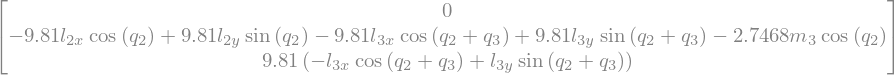

In [9]:
# 重力项最小，适合直接看。关节 1 轴与重力平行，故 g[0] 恒为 0
sympy.trigsimp(g)

In [ ]:
# 检查 Christoffel 形式 C 的一个结构性质：Ṁ - 2C 应为斜对称矩阵
S = dyn.gen_skew_symmetry()
residual = sympy.simplify(S + S.T)
print("S + S^T =", residual.T.tolist())
assert residual == sympy.zeros(*residual.shape)


In [11]:
# 数值对拍：符号 tau = M ddq + c + g 应等于 MuJoCo 的 mj_inverse
ddq_test = np.array([0.2, 0.3, -0.5])
args = list(robot.q) + list(robot.symbols.dq) + list(robot.symbols.ddq)
tau_fun = sympy.lambdify(args + list(dyn.dynparms), tau, "numpy")

tau_sym = np.asarray(
    tau_fun(*q_test, *dq_test, *ddq_test, *ref.dynparms()), dtype=float
).ravel()
tau_mj = ref.inverse_dynamics(q_test, dq_test, ddq_test)
print("符号:", tau_sym)
print("MuJoCo:", tau_mj)
print(f"误差 {np.abs(tau_sym - tau_mj).max():.2e}")

符号: [-5.62628743e-03 -6.91030548e+00 -1.25855756e+00]
MuJoCo: [-5.62628743e-03 -6.91030548e+00 -1.25855756e+00]
误差 7.11e-15


## 4. 导出公式并回读

`robot.export` 支持 Python、C 和 LaTeX。提供路径时写入文件，否则返回文本。生成函数的 `q / dq / ddq / parms` 均使用一维数组，文件头记录完整参数的排列顺序。

这里同时导出完整回归矩阵 `H`、基参数回归矩阵 `Hb` 和参数映射 `baseparms`。生成后回读 Python 模块，检查 `tau`、`H @ pi` 和 `Hb @ pi_b` 是否都与 MuJoCo 一致。


In [12]:
print("可导出的量:", robot.export.available_keys)
print("默认导出:", robot.export.default_keys)

可导出的量: ('T', 'J', 'M', 'c', 'C', 'g', 'tau', 'H', 'Hb', 'baseparms')
默认导出: ('T', 'J', 'M', 'c', 'g', 'tau')


In [ ]:
# 导出 H / Hb / baseparms 时会自动生成回归矩阵并计算基参数。
keys = ("T", "J", "M", "c", "C", "g", "tau", "H", "Hb", "baseparms")

py_path = robot.export.python(OUT / "rrr_dynamics.py", keys=keys)
c_path = robot.export.c(OUT / "rrr_dynamics.c", keys=keys)
tex_path = robot.export.latex(OUT / "rrr_dynamics.tex", keys=("T", "J", "M", "g"))

for p in (py_path, c_path, tex_path):
    print(f"{p.name:22s} {p.stat().st_size / 1024:8.1f} KB")


In [ ]:
# 回读生成的 Python 模块，确认能直接用
spec = importlib.util.spec_from_file_location("rrr_dynamics", py_path)
gen = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gen)

print([n for n in dir(gen) if not n.startswith("_")])
tau_gen = np.asarray(
    gen.tau(q_test, dq_test, ddq_test, ref.dynparms()), dtype=float
).ravel()
print(f"生成代码 vs MuJoCo 误差 {np.abs(tau_gen - tau_mj).max():.2e}")

# 回归矩阵形式：tau = H pi = Hb pi_b，两条都该等于 tau
p_true = ref.dynparms()
print(f"H {gen.H(q_test, dq_test, ddq_test).shape}", end="  ")
print(f"Hb {gen.Hb(q_test, dq_test, ddq_test).shape}", end="  ")
print(f"baseparms {gen.baseparms(p_true).shape}")
print(f"H pi   误差 {np.abs(gen.H(q_test, dq_test, ddq_test) @ p_true - tau_mj).max():.2e}")
print(
    "Hb pi_b 误差"
    f" {np.abs(gen.Hb(q_test, dq_test, ddq_test) @ gen.baseparms(p_true) - tau_mj).max():.2e}"
)


## 5. 用导出的回归矩阵辨识

完整 `H` 存在相关列，完整惯性参数因而不能直接唯一辨识。下面拟合独立的基参数，使用刚导出的 `gen.Hb` 和 `gen.baseparms`，同时检验这些函数能否接入辨识接口。


In [ ]:
# H 与基参数已在上一节导出时算好，这里只看结果
print(f"完整参数 {dyn.n_dynparms} 个 → 基参数 {dyn.n_base} 个")
print("前 3 个基参数（原参数的线性组合）:")
for expr in list(dyn.baseparms)[:3]:
    print("   ", sympy.expand(expr))


In [ ]:
# 导出的 Hb 返回 (dof, n_base) 数组，可直接传给 identify。
Hb_func = gen.Hb

# MJCF 真参数投到基参数空间，作为辨识的比对真值
pi_b_true = gen.baseparms(ref.dynparms())
print("pi_b 真值:", np.round(pi_b_true, 4))


In [ ]:
# 在候选轨迹中选择条件数较小的一条，以减轻参数拟合对噪声的敏感性。
rng = np.random.default_rng(0)
traj, cond = search_excitation(Hb_func, robot.dof, rng, trials=20, vel_scale=1.2)
print(f"cond(W) = {cond:.3g}")

q_pk, dq_pk, ddq_pk = traj.peak_values()
print("峰值 |q|:", np.round(q_pk, 3))
print("峰值 |dq|:", np.round(dq_pk, 3))
print("峰值 |ddq|:", np.round(ddq_pk, 3))


In [18]:
data = sample_trajectory(traj, ref.inverse_dynamics, rate=100)
result = identify(Hb_func, data)
print(result.summary())
print("相对误差:", parameter_error(result.parms, pi_b_true)["rel_norm"])

15 个参数 / 1000 个采样点，cond=36.6，残差 RMS=3.28e-15（相对 0.00%）
相对误差: 3.983556728423754e-15


In [ ]:
# 只给力矩加高斯噪声，观察参数拟合的敏感性；这还不是闭环采集实验。
for std in (0.0, 0.01, 0.05, 0.2):
    noisy = data if std == 0 else add_noise(data, np.random.default_rng(1), tau_std=std)
    res = identify(Hb_func, noisy)
    err = parameter_error(res.parms, pi_b_true)["rel_norm"]
    print(f"tau_std={std:<5} 参数相对误差 {err:.3e}  残差 RMS {res.residual_rms:.3e}")


## 6. 由基参数计算 M / c / g

基参数是完整惯性参数的线性组合，通常不能唯一还原每根连杆的质量、质心和惯量。对于这里的纯刚体模型，`DynamicsDecomposer` 用下列关系计算惯性、速度和重力项，无需先恢复完整参数：

$$g(q) = H_b(q, 0, 0)\,\pi_b, \quad M(q)_{:,i} = H_b(q, 0, e_i)\,\pi_b - g(q), \quad c(q,\dot q) = H_b(q, \dot q, 0)\,\pi_b - g(q)$$

下面先与符号公式、MuJoCo 质量矩阵和重力力矩比较，再检查多个随机构型。


In [20]:
dec = DynamicsDecomposer(Hb_func, result.parms, robot.dof)
terms = dec.at(q_test, dq_test)

print("M =\n", np.round(terms.M, 6))
print("c =", np.round(terms.c, 6))
print("g =", np.round(terms.g, 6))
print(f"\nM 非对称度 {terms.symmetry_error():.2e}（理论为 0）")

M =
 [[ 0.200604 -0.011609  0.002576]
 [-0.011609  0.231013  0.041536]
 [ 0.002576  0.041536  0.02024 ]]
c = [-0.040976 -0.017467  0.010059]
g = [ 0.       -6.939052 -1.271472]

M 非对称度 6.66e-16（理论为 0）


In [21]:
# 对照 1：符号 M / c / g（用导出的代码 + MJCF 真参数）
M_sym = gen.M(q_test, p_true)
c_sym = gen.c(q_test, dq_test, p_true)
g_sym = gen.g(q_test, p_true)

print(f"M 误差 {np.abs(terms.M - M_sym).max():.2e}")
print(f"c 误差 {np.abs(terms.c - c_sym).max():.2e}")
print(f"g 误差 {np.abs(terms.g - g_sym).max():.2e}")

M 误差 2.25e-15
c 误差 3.05e-16
g 误差 5.55e-15


In [22]:
# 对照 2：MuJoCo 的质量矩阵（mj_fullM）与重力力矩
d = mujoco.MjData(model)
d.qpos[:] = q_test
mujoco.mj_forward(model, d)
M_mj = np.zeros((model.nv, model.nv))
mujoco.mj_fullM(model, M_mj, d.qM)
g_mj = ref.inverse_dynamics(q_test, np.zeros(3), np.zeros(3))

print(f"M vs mj_fullM     {np.abs(terms.M - M_mj).max():.2e}")
print(f"g vs mj_inverse   {np.abs(terms.g - g_mj).max():.2e}")

M vs mj_fullM     1.78e-15
g vs mj_inverse   7.11e-15


In [23]:
# 重组自检：M ddq + c + g 应还原力矩
print("重组:", terms.torque(ddq_test))
print("真值:", tau_mj)
print(f"误差 {np.abs(terms.torque(ddq_test) - tau_mj).max():.2e}")

重组: [-5.62628743e-03 -6.91030548e+00 -1.25855756e+00]
真值: [-5.62628743e-03 -6.91030548e+00 -1.25855756e+00]
误差 8.88e-15


In [ ]:
# 在 50 个随机构型上比较分解结果，补充单点检查。
rng_chk = np.random.default_rng(7)
errs = {"M": [], "c": [], "g": [], "tau": []}
for _ in range(50):
    qa, dqa, ddqa = (rng_chk.uniform(-1.5, 1.5, 3) for _ in range(3))
    tm = dec.at(qa, dqa)
    errs["M"].append(np.abs(tm.M - gen.M(qa, p_true)).max())
    errs["c"].append(np.abs(tm.c - gen.c(qa, dqa, p_true)).max())
    errs["g"].append(np.abs(tm.g - gen.g(qa, p_true)).max())
    errs["tau"].append(np.abs(tm.torque(ddqa) - ref.inverse_dynamics(qa, dqa, ddqa)).max())

for k, v in errs.items():
    print(f"{k:4s} 最大误差 {max(v):.3e}")


### 沿轨迹查看力矩分量

每隔五个采样点绘制一次，比较 `M ddq + c + g` 与 `mj_inverse` 生成的力矩。这里使用连续的理想轨迹，没有速度筛选造成的间隔。


In [ ]:
idx = np.arange(0, data.n_samples, 5)
components = [dec.at(data.q[i], data.dq[i]) for i in idx]
Mddq = np.array([terms.M @ data.ddq[i] for terms, i in zip(components, idx)])
c_tr = np.array([terms.c for terms in components])
g_tr = np.array([terms.g for terms in components])
tau_tr = Mddq + c_tr + g_tr

fig, axes = plt.subplots(robot.dof, 1, figsize=(8, 6), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(data.t[idx], Mddq[:, j], label=r"$M\ddot q$")
    ax.plot(data.t[idx], c_tr[:, j], label="c")
    ax.plot(data.t[idx], g_tr[:, j], label="g")
    ax.plot(data.t[idx], tau_tr[:, j], "k--", lw=1, label="sum")
    ax.plot(data.t[idx], data.tau[idx, j], ":", label="mj_inverse")
    ax.set_ylabel(f"Joint {j+1} / N m")
    ax.grid(True, alpha=0.3)
axes[0].legend(ncol=5, fontsize=8)
axes[-1].set_xlabel("Time / s")
fig.suptitle("RRR torque components from identified base parameters")
fig.tight_layout()
plt.show()


### 力矩噪声对分解结果的影响

无噪声时，辨识和参考模型使用相同的动力学，因此误差应接近数值精度。加噪声后，基参数误差会传到 `M / c / g`；不同状态和不同分量的误差大小不一定相同。这里仍在同一个构型比较，便于观察噪声强度的影响。


In [25]:
print(f"{'tau_std':>8} {'pi_b 误差':>12} {'M 误差':>12} {'g 误差':>12}")
for std in (0.0, 0.01, 0.05, 0.2):
    noisy = data if std == 0 else add_noise(data, np.random.default_rng(1), tau_std=std)
    parms = identify(Hb_func, noisy).parms
    tm = DynamicsDecomposer(Hb_func, parms, robot.dof).at(q_test, dq_test)
    print(
        f"{std:>8} {parameter_error(parms, pi_b_true)['rel_norm']:>12.3e}"
        f" {np.abs(tm.M - M_sym).max():>12.3e} {np.abs(tm.g - g_sym).max():>12.3e}"
    )

 tau_std      pi_b 误差         M 误差         g 误差
     0.0    3.984e-15    2.248e-15    5.551e-15
    0.01    1.212e-03    4.059e-04    5.507e-04
    0.05    6.059e-03    2.030e-03    2.753e-03
     0.2    2.423e-02    8.118e-03    1.101e-02


## 7. 可选：恢复连杆质量、质心和惯量

需要把参数写回仿真模型时，可用 `recover_inertial_parameters` 在基参数拟合与物理约束之间求一组完整参数。解通常不唯一；`success` 同时要求求解器收敛、物理可行和基参数误差合格。

把下一格的 `RUN_RECOVERY` 改为 `True` 后运行。本节读取 [当前恢复配置](../../configs/rrr/recovery.json)，保留其中的质量范围、质心范围、尺寸包络和名义参数软先验，只缩短搜索预算。先验取自仓库的未扰动 MJCF，不从验证误差或真值扰动构造。

**本例生成数据的模型与名义模型来自同一个 MJCF**，所以这只能演示恢复接口和验收信息，不能验证未知物理参数的恢复能力。README 的闭环实验分别使用未扰动名义模型与扰动后的仿真模型。短预算可能不收敛，失败候选只能用于诊断。


In [ ]:
RUN_RECOVERY = False
recovered = None

if RUN_RECOVERY:
    config_path = _ROOT / "configs" / "rrr" / "recovery.json"
    cfg = replace(
        RecoveryConfig(**json.loads(config_path.read_text(encoding="utf-8"))),
        runs=1,
        annealing_maxiter=5,
        local_maxiter=200,
        seed=0,
    )
    nominal_model = mujoco.MjModel.from_xml_path(str(rrr_xml_path()))
    nominal_ref = MujocoReference(nominal_model, RRR_BODY_NAMES)
    nominal = pack_inertial_parameters(
        robot,
        np.array([link.m for link in nominal_ref.links]),
        np.array([link.r for link in nominal_ref.links]),
        np.array([link.I for link in nominal_ref.links]),
    )
    recovered = recover_inertial_parameters(
        robot, result.parms, nominal_parameters=nominal, config=cfg,
    )
    r = recovered.report
    print(
        f"success={recovered.success}  "
        f"solver={r['solver_success']}  "
        f"feasible={r['physical_feasible']}  "
        f"geometry={r['geometry_feasible']}  "
        f"matches_base={r['matches_base']}  "
        f"base_error={r['base_error']:.3e}"
    )
    if not recovered.success:
        print("未通过验收；候选仅供诊断，辨识基参数仍以 result.parms 为准。")
else:
    print("已跳过可选恢复。将 RUN_RECOVERY 改为 True 后运行本节。")


In [ ]:
if recovered is not None:
    # 求解结束后再读取参考值。由于本例同源，只作为接口演示的对照。
    truth_m = np.array([link.m for link in ref.links])
    truth_c = np.array([link.r for link in ref.links])
    truth_I = np.array([link.I for link in ref.links])
    print(f"{'link':>4} {'m_rec':>8} {'m_ref':>8} {'|Δm|':>8}  CoM_rec / CoM_ref")
    for i in range(robot.dof):
        dm = abs(recovered.masses[i] - truth_m[i])
        print(
            f"{i+1:>4} {recovered.masses[i]:>8.4f} {truth_m[i]:>8.4f} {dm:>8.4f}  "
            f"{np.round(recovered.centers_of_mass[i], 4)} / {np.round(truth_c[i], 4)}"
        )
    print(f"总质量  rec={recovered.masses.sum():.4f}  ref={truth_m.sum():.4f}")
    print("\n质心惯性张量对角元 (Ixx, Iyy, Izz)：")
    for i in range(robot.dof):
        print(
            f"  link{i+1}  rec={np.round(np.diag(recovered.inertias_com[i]), 5)}  "
            f"ref={np.round(np.diag(truth_I[i]), 5)}"
        )


In [ ]:
if recovered is not None:
    tau_id = predict_torque(Hb_func, data, result.parms)
    tau_rec = predict_torque(Hb_func, data, recovered.base_parameters)
    print(f"辨识 vs 恢复 力矩 RMS {np.sqrt(np.mean((tau_id - tau_rec) ** 2)):.3e}")
    print(f"恢复 vs 生成数据 力矩 RMS {np.sqrt(np.mean((tau_rec - data.tau) ** 2)):.3e}")

    tau_mj_pt = ref.inverse_dynamics(q_test, dq_test, ddq_test)
    tau_rec_pt = Hb_func(q_test, dq_test, ddq_test) @ recovered.base_parameters
    print(f"单点 |τ_rec - τ_mj| max {np.abs(tau_rec_pt - tau_mj_pt).max():.3e}")


若要运行带跟踪误差、测量噪声和预处理的闭环实验，可在仓库根目录执行：

```bash
python -m robot_model.cli.identify_rrr --realistic --recover-inertia \
  --recovery-config configs/rrr/recovery.json \
  --output-dir outputs/rrr/recovered
```

配置依据、独立验证结果以及完整参数的非唯一性，见 [README](../../README.md) 和 [工程原理](../../docs/principles.md)。
